# Exercício 1

Utilizando o método ingênuo gere uma amostra de tamanho $M=1000$ de uma variável geométrica com parâmetro $p$. Compara o gráfico da sua distribuição com a função do numpy. Além disso, compare o que acontece quando você varia o valor $p$

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

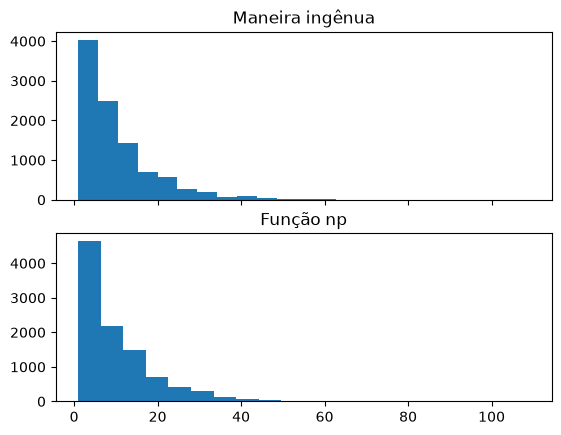

In [2]:
M = 10000
p = 0.1
i = 1
def geo(p):
    i = 1
    while np.random.uniform() > p:
        i += 1
    return i

amostra1 = np.array([geo(p) for _ in range(M)])
amostra2 = np.random.geometric(p, size = M)
fig, ax = plt.subplots(2, sharex=True)
ax[0].hist(amostra1, bins = 20)
ax[0].set_title('Maneira ingênua')
ax[1].hist(amostra2, bins = 20)
ax[1].set_title('Função np')
plt.show()

# Exercício 2

Repita o exercício anterior, porém utilizando o método de inversão. Compare o tempo gasto por esse método versus o método ingênuo do item anterior usando a função `time.time` variando o $p$, ou seja, no eixo $y$ coloque o tempo e no eixo $x$ coloque $p$.

In [3]:
def geo_inversa(p):
    u = np.random.uniform()
    return np.ceil(np.log(u)/np.log(1-p))
amostra3 = [geo_inversa(p) for _ in range(M)]

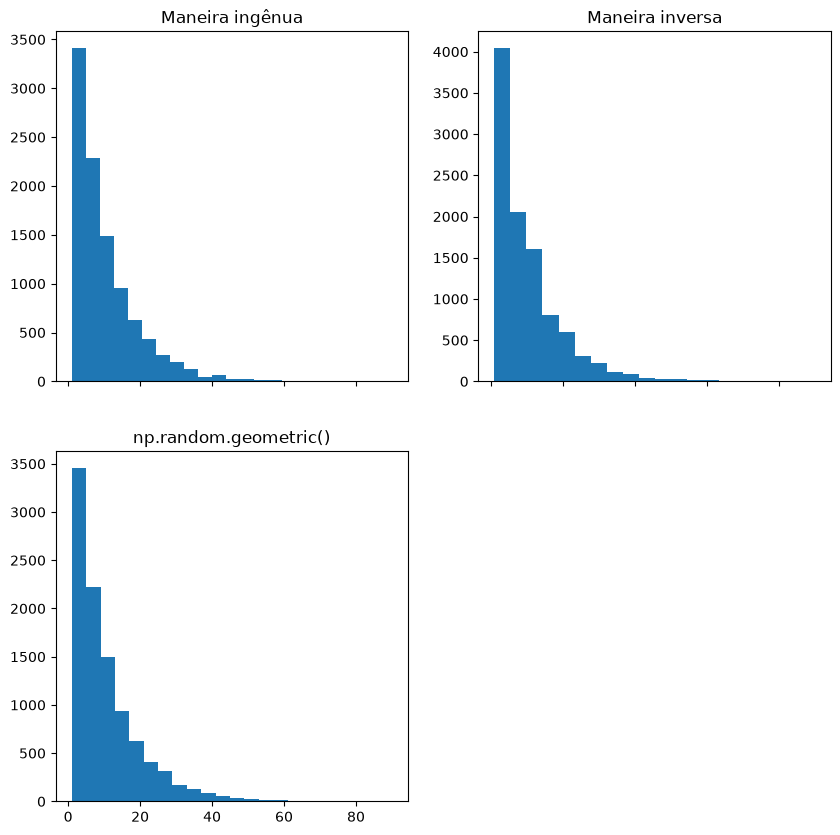

In [4]:
amostra1 = np.array([geo(p) for _ in range(M)])
amostra2 = np.random.geometric(p, size = M)
fig, ax = plt.subplots(2, 2, sharex=True, figsize = (10,10))
ax[0][0].hist(amostra1, bins = 20)
ax[0][0].set_title('Maneira ingênua')
ax[1][0].hist(amostra2, bins = 20)
ax[1][0].set_title('np.random.geometric()')
ax[0][1].hist(amostra3, bins = 20)
ax[0][1].set_title('Maneira inversa')
ax[1][1].remove()
plt.show()

In [5]:
tempo1 = []
for p in np.linspace(0.01,0.99):
    inicio = time.time()
    amostra1 = np.array([geo(p) for _ in range(M)])
    tempo1.append((p, time.time()-inicio))
tempo2 = []
for p in np.linspace(0.01,0.99):
    inicio = time.time()
    amostra2 = np.array([geo_inversa(p) for _ in range(M)])
    tempo2.append((p, time.time()-inicio))


In [6]:
tempo1 = np.array(tempo1)
tempo2 = np.array(tempo2)

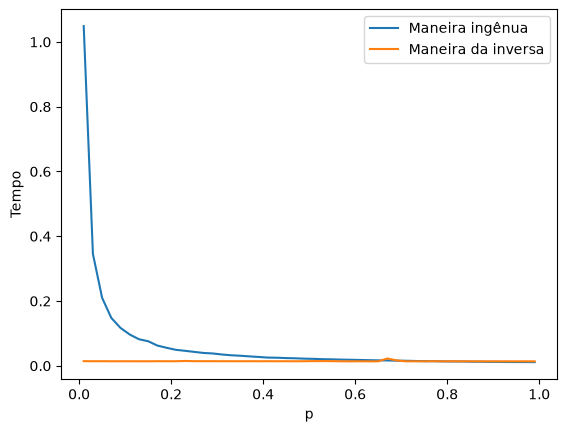

In [7]:
fig, ax = plt.subplots()
ax.plot(tempo1[:,0], tempo1[:,1], label = 'Maneira ingênua')
ax.plot(tempo2[:,0], tempo2[:,1], label = 'Maneira da inversa')
plt.legend()
plt.xlabel('p')
plt.ylabel('Tempo')
plt.show()

# Exercício 3

Gere uma amostra de tamanho $M=1000$ de uma Poisson com parâmetro $\\lambda$ usando o método recursivo.


In [8]:
def pois(lamb):
    u = np.random.uniform()
    i = 0
    p = np.exp(-lamb)
    F = p
    while u > F:
        i += 1
        p *= lamb/i 
        F += p
    return i

In [25]:
M = 100000
lamb = 10
amostralamb = [pois(lamb) for _ in tqdm(range(M))]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:00<00:00, 359215.16it/s]


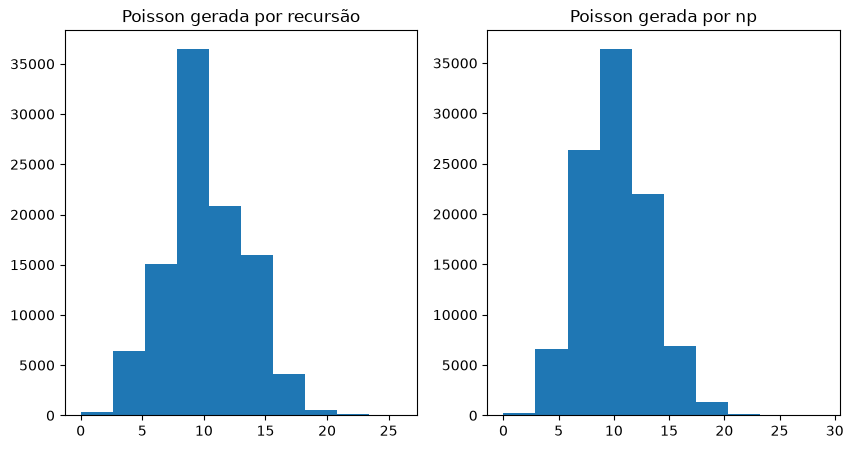

In [26]:
poisson_np = np.random.poisson(lamb, size= M)
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].hist(amostralamb)
ax[1].hist(poisson_np)
ax[0].set_title('Poisson gerada por recursão')
ax[1].set_title('Poisson gerada por np')
plt.show()